# Sephora Ingredient Graph + Recommendation System
Builds ingredient networks, runs PageRank and Louvain community detection, and adds a user review + skin-type layer for recommendations.

## 1. Imports

In [1]:
from neo4j import GraphDatabase
from dotenv import load_dotenv, find_dotenv
import networkx as nx
import community as community_louvain
import pandas as pd
import os
import matplotlib.pyplot as plt

## 2. Load Environment

In [2]:
load_dotenv(find_dotenv(), override=True)

URI = os.getenv("NEO4J_URI")
AUTH = (os.getenv("NEO4J_USER"), os.getenv("NEO4J_PASSWORD"))

driver = GraphDatabase.driver(URI, auth=AUTH)
print("Connected to Neo4j")

Connected to Neo4j


## 3. Load Ingredient Data

In [3]:
df = pd.read_csv("../data/processed/neo4j_edges.csv")

# clean ingredient column
df = df.dropna(subset=["ingredient_name"])
df["ingredient_name"] = df["ingredient_name"].str.strip()
df = df[df["ingredient_name"] != ""]

print("Cleaned rows:", df.shape)

df.head()

Cleaned rows: (81486, 4)


,ingredient_name,product_id,product_name,primary_category
0,water (aqua),P504322,Gentle Hydra-Gel Face Cleanser,Skincare
1,dipropylene glycol,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
2,peg-6 caprylic/capric glycerides,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
3,glycerin,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
4,2-hexanediol,P504322,Gentle Hydra-Gel Face Cleanser,Skincare


## 4. Clear Database

In [4]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
print("Database cleared")

Database cleared


## 5. Insert Product - Ingredient Graph

In [5]:
def load_batch(tx, batch):
    tx.run("""
        UNWIND $batch AS row 
        MERGE (i:Ingredient {name: row.ingredient_name})
        MERGE (p:Product {id: row.product_id})
          ON CREATE SET p.name = row.product_name,
                        p.primary_category = row.primary_category
        MERGE (i)-[:FOUND_IN]->(p)
    """, batch=batch)

batch_size = 5000
rows = df.to_dict("records")

with driver.session() as session:
    for i in range(0, len(rows), batch_size):
        session.execute_write(load_batch, rows[i:i+batch_size])

print("Graph loaded into Neo4j")

Graph loaded into Neo4j


In [6]:
def patch_product_properties(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        MATCH (p:Product {id: row.product_id})
        SET p.name = row.product_name,
            p.primary_category = row.primary_category
    """, batch=batch)

# get unique products from your export df
product_info = df[["product_id", "product_name", "primary_category"]].drop_duplicates()

batch_size = 5000
rows = product_info.to_dict("records")

with driver.session() as session:
    for i in range(0, len(rows), batch_size):
        session.execute_write(patch_product_properties, rows[i:i+batch_size])

print("Product properties patched")

Product properties patched


## 6. Retrieve Ingredient Relationships

In [7]:
with driver.session() as session:
    result = session.run("""
        MATCH (i:Ingredient)-[:FOUND_IN]->(p:Product)
        RETURN i.name AS ingredient, 
               p.id AS product_id,
               p.name AS product_name,
               p.primary_category AS primary_category
    """)
    edges = pd.DataFrame([r.data() for r in result])

edges.head()

,ingredient,product_id,product_name,primary_category
0,hydrolyzed hyaluronic acid,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
1,tromethamine,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
2,ethylhexylglycerin,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
3,sodium hyaluronate,P504322,Gentle Hydra-Gel Face Cleanser,Skincare
4,peg-6 caprylic/capric glycerides,P504322,Gentle Hydra-Gel Face Cleanser,Skincare


## 7. Build Co-occurrence Graph

In [8]:
product_ingredients = edges.groupby("product_id")["ingredient"].apply(list)

G = nx.Graph()

for product, ingredients in product_ingredients.items():
    for i in range(len(ingredients)):
        for j in range(i + 1, len(ingredients)):
            ing1 = ingredients[i]
            ing2 = ingredients[j]

            if G.has_edge(ing1, ing2):
                G[ing1][ing2]["weight"] += 1
            else:
                G.add_edge(ing1, ing2, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 8144
Edges: 717383


## 8. PageRank

In [9]:
pagerank_scores = nx.pagerank(G, weight="weight")

df_pagerank = pd.DataFrame([
    {"ingredient": k, "pagerank_score": v}
    for k,v in pagerank_scores.items()
]).sort_values("pagerank_score", ascending=False)

df_pagerank.head(20)

,ingredient,pagerank_score
3,glycerin,0.013689
12,phenoxyethanol,0.008902
39,butylene glycol,0.008901
53,tocopherol,0.007674
75,citric acid,0.007517
49,sodium hyaluronate,0.007160
335,xanthan gum,0.006988
598,propanediol,0.006941
16,caprylyl glycol,0.006699
221,ethylhexylglycerin,0.006500


## 9. Visualization: Top PageRank Ingredients

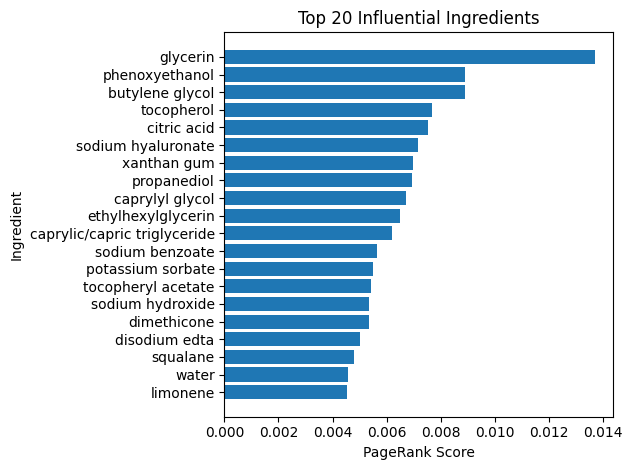

In [10]:
top = df_pagerank.head(20)

plt.figure()
plt.barh(top["ingredient"][::-1], top["pagerank_score"][::-1])
plt.xlabel("PageRank Score")
plt.ylabel("Ingredient")
plt.title("Top 20 Influential Ingredients")
plt.tight_layout()
plt.show()

## 10. Louvain Community Detection

In [11]:
partition = community_louvain.best_partition(G, weight="weight")

df_communities = pd.DataFrame([
    {"ingredient": node, "community": comm}
    for node, comm in partition.items()
])

df_communities = df_communities.merge(df_pagerank, on="ingredient")
df_communities.head()

,ingredient,community,pagerank_score
0,sodium pca,0,0.002318
1,ascorbyl palmitate,1,0.001090
2,serenoa serrulata fruit extract,2,0.000082
3,glycerin,1,0.013689
4,borago officinalis seed oil,3,0.000306


## 11. Visualization: Community Sizes

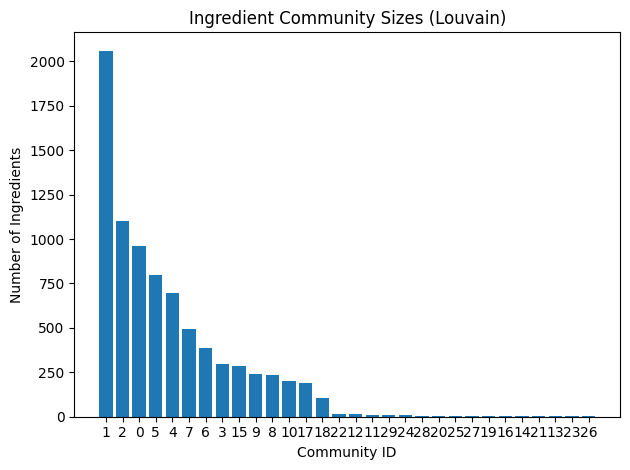

In [12]:
community_sizes = df_communities.groupby("community").size().sort_values(ascending=False)

plt.figure()
plt.bar(community_sizes.index.astype(str), community_sizes.values)
plt.xlabel("Community ID")
plt.ylabel("Number of Ingredients")
plt.title("Ingredient Community Sizes (Louvain)")
plt.tight_layout()
plt.show()

## 12. Write Results Back to Neo4j

In [13]:
def write_pagerank(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        MATCH (i:Ingredient {name: row.ingredient})
        SET i.pagerank = row.pagerank_score
    """, batch=batch)

with driver.session() as session:
    session.execute_write(write_pagerank, df_pagerank.to_dict("records"))

print("PageRank written to Neo4j")

PageRank written to Neo4j


In [14]:
def write_community(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        MATCH (i:Ingredient {name: row.ingredient})
        SET i.community = row.community
    """, batch=batch)

with driver.session() as session:
    session.execute_write(write_community, df_communities.to_dict("records"))

print("Communities written to Neo4j")

Communities written to Neo4j


## 13. Load Reviews Dataset

In [15]:
reviews = pd.read_csv("../data/processed/reviews.csv")
reviews = reviews.dropna(subset=["skin_type"])
reviews.head()

,author_id,product_id,rating,skin_type,review_text,review_id
0,1741593524,P504322,5,dry,I use this with the Nudestix “Citrus Clean Bal...,1
2,5061282401,P420652,5,dry,My review title says it all! I get so excited ...,3
3,6083038851,P420652,5,combination,I’ve always loved this formula for a long time...,4
4,47056667835,P420652,5,combination,"If you have dry cracked lips, this is a must h...",5
5,42802569154,P420652,4,normal,The scent isn’t my favourite but it works grea...,6


## 14. Build User–Review–SkinType Graph

In [16]:
def load_reviews(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        
        MERGE (u:User {id: row.author_id})
        MERGE (p:Product {id: row.product_id})
        MERGE (s:SkinType {type: row.skin_type})

        MERGE (u)-[:HAS_SKIN_TYPE]->(s)

        MERGE (u)-[r:REVIEWED {id: row.review_id}]->(p)
        SET r.rating = row.rating,
            r.text = row.review_text
    """, batch=batch)

In [17]:
batch_size = 20000
rows = reviews.to_dict("records")

with driver.session() as session:
    for i in range(0, len(rows), batch_size):
        batch = rows[i:i+batch_size]
        session.execute_write(load_reviews, batch)
        print(f"Loaded {i+len(batch)} reviews")

print("User review graph created")

Loaded 20000 reviews
Loaded 40000 reviews
Loaded 60000 reviews
Loaded 80000 reviews
Loaded 100000 reviews
Loaded 120000 reviews
Loaded 140000 reviews
Loaded 160000 reviews
Loaded 180000 reviews
Loaded 200000 reviews
Loaded 220000 reviews
Loaded 240000 reviews
Loaded 260000 reviews
Loaded 280000 reviews
Loaded 300000 reviews
Loaded 320000 reviews
Loaded 340000 reviews
Loaded 360000 reviews
Loaded 380000 reviews
Loaded 400000 reviews
Loaded 420000 reviews
Loaded 440000 reviews
Loaded 460000 reviews
Loaded 480000 reviews
Loaded 500000 reviews
Loaded 520000 reviews
Loaded 540000 reviews
Loaded 560000 reviews
Loaded 580000 reviews
Loaded 600000 reviews
Loaded 620000 reviews
Loaded 640000 reviews
Loaded 660000 reviews
Loaded 680000 reviews
Loaded 700000 reviews
Loaded 720000 reviews
Loaded 740000 reviews
Loaded 760000 reviews
Loaded 780000 reviews
Loaded 800000 reviews
Loaded 820000 reviews
Loaded 840000 reviews
Loaded 860000 reviews
Loaded 880000 reviews
Loaded 900000 reviews
Loaded 920000 

## 15. Recommendation Query

In [18]:
with driver.session() as session:
    result = session.run("""
        MATCH (s:SkinType {type:'oily'})<-[:HAS_SKIN_TYPE]-(u:User)
        MATCH (u)-[r:REVIEWED]->(p:Product)

        WITH p,
             avg(r.rating) AS avg_rating,
             count(r) AS reviews

        WHERE reviews >= 50

        RETURN p.id AS product,
               round(avg_rating,2) AS rating,
               reviews
        ORDER BY rating DESC, reviews DESC
        LIMIT 10
    """)

    recommendations = pd.DataFrame([r.data() for r in result])

recommendations

,product,rating,reviews
0,P505009,4.84,79
1,P503936,4.81,128
2,P505023,4.79,86
3,P12573,4.78,249
4,P479841,4.78,118
5,P483679,4.77,57
6,P481831,4.76,108
7,P482264,4.76,76
8,P387261,4.75,56
9,P173726,4.74,246


In [19]:
with driver.session() as session:
    result = session.run("""
        MATCH (s:SkinType {type:'oily'})<-[:HAS_SKIN_TYPE]-(u:User)
        MATCH (u)-[r:REVIEWED]->(p:Product)

        WITH p,
             avg(r.rating) AS avg_rating,
             count(r) AS reviews,
             (avg(r.rating) * log10(count(r)+1)) AS score

        WHERE reviews >= 50

        RETURN p.id AS product_id,
               p.name AS product_name,
               p.primary_category AS category,
               round(avg_rating, 2) AS rating,
               reviews,
               round(score, 3) AS score
        ORDER BY score DESC
        LIMIT 10
    """)

    recommendations = pd.DataFrame([r.data() for r in result])

recommendations

,product_id,product_name,category,rating,reviews,score
0,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,Skincare,4.35,2087,14.454
1,P427417,Niacinamide 10% + Zinc 1% Oil Control Serum,Skincare,4.27,1351,13.381
2,P394639,The True Cream Aqua Bomb,Skincare,4.48,934,13.302
3,P122900,Dramatically Different Moisturizing Gel,Skincare,4.50,885,13.275
4,P417238,Green Clean Makeup Removing Cleansing Balm,Skincare,4.55,776,13.145
5,P450271,Green Clean Makeup Meltaway Cleansing Balm Lim...,Skincare,4.55,776,13.145
6,P269122,Alpha Beta Extra Strength Daily Peel Pads,Skincare,4.53,785,13.116
7,P423688,Daily Microfoliant Exfoliator,Skincare,4.65,592,12.891
8,P443352,Mini Daily Microfoliant Exfoliator,Skincare,4.65,592,12.891
9,P442563,AHA 30% + BHA 2% Exfoliating Peeling Solution,Skincare,4.62,556,12.672
